In [3]:
import pandas as pd
import sys
sys.path.append("../..")

In [4]:
from paper.plotting_functions import plot_pareto
from paper.bench_utils import load

# Sweep pareto

In [5]:
def preprocess_df(
        version, metric, specific_dataset=None, 
        normalize_latency=True, normalize_accuracy=True,
):
    samples = load(version, "results")
    df = pd.json_normalize([s.__dict__ for s in samples])
    df = df.rename(columns={"name": "method"})
    df["param"] = df.apply(
        lambda row: row[f"setup.{row['sweep_param']}"] if pd.notna(row["sweep_param"]) else None,
        axis=1,
    )
    if normalize_accuracy:
        dense_means = (
            df[df["method"] == "dense"]
            .groupby("setup.dataset")[metric]
            .mean()
        )
        df[metric] = df[metric] / df["setup.dataset"].map(dense_means)
    if normalize_latency:
        dense_latency_means = (
            df[df["method"] == "dense"]
            .groupby("setup.dataset")["latency"]
            .mean()
        )
        df["latency"] = df["latency"] / df["setup.dataset"].map(dense_latency_means)
    if specific_dataset:
        df = df[df["setup.dataset"]==specific_dataset]
    return df

In [6]:
denses = {
    "dense": "Dense",
    "dense_sage": "Dense using SageAttention",
}
topks = {
    "random_topk": "Random Clusters",
    "clusterattention_topk": "ClusterAttention",
    "clusterattention_topk_finecomp": "ClusterAttention w/ striped comp",
}
adaptives = {
    "svoo": "SVOO",
    "clusterattention_adaptive": "ClusterAttention (adaptive)",
    "clusterattention_adaptive_finecomp": "ClusterAttention (adaptive) w/ striped comp",
}
others = {
  "nyström": "Nyström",
  "vyas-cluster-nobias": "Vyas Clustered (no bias)",
  "vyas-cluster": "Vyas Clustered"
}
name_map_pareto = (
  # denses | adaptives  
  denses | topks | adaptives | others
)

method_colors = {
    "dense": "#d62728",
    "dense_sage": "#ff7f0e",
    "random_topk": "#ffbb78",
    "random_topk_10k": "#ffbb78",
    "svoo": "#9467bd",
    "svoo_10k": "#9467bd",
    "clusterattention_topk": "#aec7e8",
    "clusterattention_topk_finecomp": "#1f77b4",
    "clusterattention_topk_finecomp_10k": "#1f77b4",
    "clusterattention_adaptive": "#98df8a",
    "clusterattention_adaptive_finecomp": "#2ca02c",
    "nyström": "#000000",
    "vyas-cluster-nobias": "#aaaaaa",
    "vyas-cluster": "#aaaaaa"
}

Note: SVOO uses same-size warmup due to first-run overhead on new sizes
ClusterAttention (adaptive): 0.9 time units @ 0.99 metric units
ClusterAttention: 0.8 time units @ 0.99 metric units
ClusterAttention w/ striped comp: 0.4 time units @ 0.99 metric units
Random Clusters: 0.7 time units @ 0.99 metric units
SVOO: 2.3 time units @ 0.99 metric units


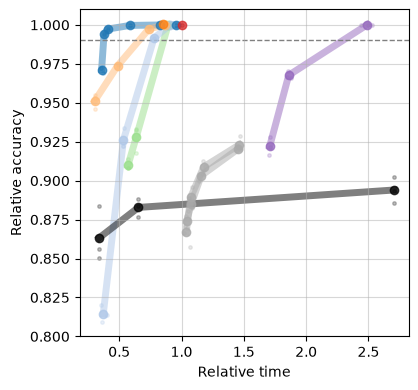

In [7]:
# normalized accuracies and latencies
version = "accelerometer"
metric = "evals.accuracy"
specific_dataset = None

df = preprocess_df(version, metric, specific_dataset)
print("Note: SVOO uses same-size warmup due to first-run overhead on new sizes")
plot_pareto(
    {"TabPFN-3": df}, 
    threshold=0.99,
    show_annotations=False, 
    show_legend=False, 
    name_map=name_map_pareto,
    #time_col=("latency", "Time (ms)"),
    time_col=("latency", "Relative time"),
    metric_col=("evals.accuracy", "Relative accuracy"),
    method_colors=method_colors,
    figsize=(4.25, 4.25)
)

Note: SVOO uses same-size warmup due to first-run overhead on new sizes
ClusterAttention w/ striped comp: 0.4 time units @ 0.99 metric units
Random Clusters: 0.7 time units @ 0.99 metric units
SVOO: 1.8 time units @ 0.99 metric units


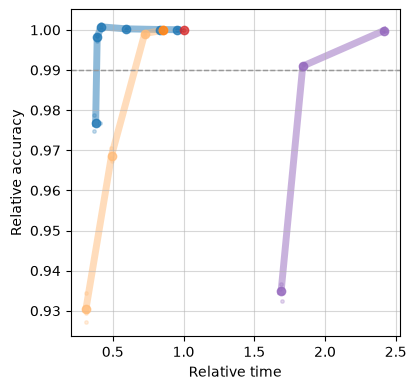

In [8]:
version = "walking-activity"
metric = "evals.accuracy"
specific_dataset = None

df = preprocess_df(version, metric, specific_dataset)
print("Note: SVOO uses same-size warmup due to first-run overhead on new sizes")
plot_pareto(
    {"TabPFN-3": df}, 
    threshold=0.99,
    show_annotations=False, 
    show_legend=False, 
    name_map=name_map_pareto,
    time_col=("latency", "Relative time"),
    metric_col=("evals.accuracy", "Relative accuracy"),
    method_colors=method_colors,
    figsize=(4.25, 4.25)
)

ClusterAttention w/ striped comp: 0.5 time units @ 0.99 metric units
Random Clusters: 0.5 time units @ 0.99 metric units


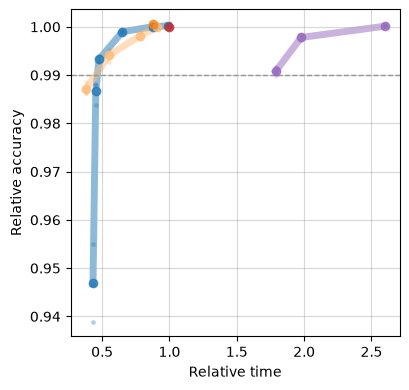

In [9]:
version = "Rain_in_Australia"
metric = "evals.accuracy"
specific_dataset = None

df = preprocess_df(version, metric, specific_dataset)
#print("Note: SVOO uses same-size warmup due to first-run overhead on new sizes")
plot_pareto(
    {"TabPFN-3": df}, 
    threshold=0.99,
    show_annotations=False, 
    show_legend=False, 
    name_map=name_map_pareto,
    time_col=("latency", "Relative time"),
    metric_col=("evals.accuracy", "Relative accuracy"),
    method_colors=method_colors,
    figsize=(4.25, 4.25)
)

Random Clusters: 0.4 time units @ 0.99 metric units
SVOO: 1.3 time units @ 0.99 metric units


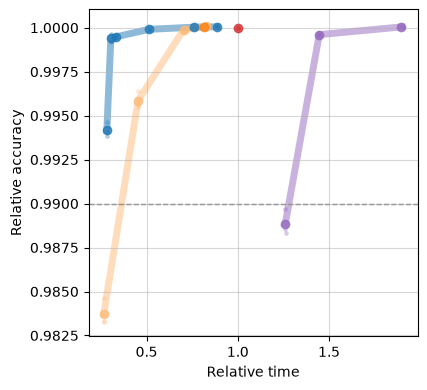

In [10]:
version = "dataset_150k"
metric = "evals.accuracy"

df = preprocess_df(version, metric)
#print("Note: SVOO uses same-size warmup due to first-run overhead on new sizes")
plot_pareto(
    {"TabPFN-3": df}, 
    threshold=0.99,
    show_annotations=False, 
    show_legend=False,
    name_map=name_map_pareto,
    #time_col=("latency", "Time (ms)"),
    time_col=("latency", "Relative time"),
    metric_col=("evals.accuracy", "Relative accuracy"),
    method_colors=method_colors,
    figsize=(4.25, 4.25)
)

ClusterAttention w/ striped comp: 0.2 time units @ 0.99 metric units


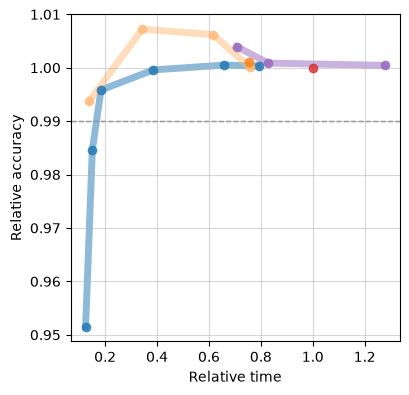

In [11]:
version = "dataset_400k"
metric = "evals.accuracy"

df = preprocess_df(version, metric)
#print("Note: SVOO uses same-size warmup due to first-run overhead on new sizes")
plot_pareto(
    {"TabPFN-3": df}, 
    threshold=0.99,
    show_annotations=False, 
    show_legend=False, 
    name_map=name_map_pareto,
    time_col=("latency", "Relative time"),
    metric_col=("evals.accuracy", "Relative accuracy"),
    method_colors=method_colors,
    figsize=(4.25, 4.25)
)

ClusterAttention w/ striped comp: 0.1 time units @ 0.99 metric units
Random Clusters: 0.2 time units @ 0.99 metric units
SVOO: 1.2 time units @ 0.99 metric units


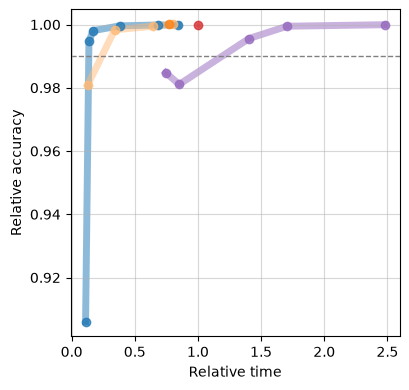

In [12]:
version = "dataset_600k"
metric = "evals.accuracy"

df = preprocess_df(version, metric)
#print("Note: SVOO uses same-size warmup due to first-run overhead on new sizes")
plot_pareto(
    {"TabPFN-3": df}, 
    threshold=0.99,
    show_annotations=False, 
    show_legend=False, 
    name_map=name_map_pareto,
    time_col=("latency", "Relative time"),
    metric_col=("evals.accuracy", "Relative accuracy"),
    method_colors=method_colors,
    figsize=(4.25, 4.25)
)